,metal,adsorbate,E_adsorption_eV
0,ScN,Li2S,1.841109
1,ScN,Li2S2,2.790235
2,ScN,Li2S4,1.909215
3,ScN,Li2S6,2.054941
4,ScN,Li2S8,3.985248
5,ScN,S8,2.011970
6,VN,Li2S,3.694724
7,VN,Li2S2,3.842681
8,VN,Li2S4,3.595980
9,VN,Li2S6,4.833781


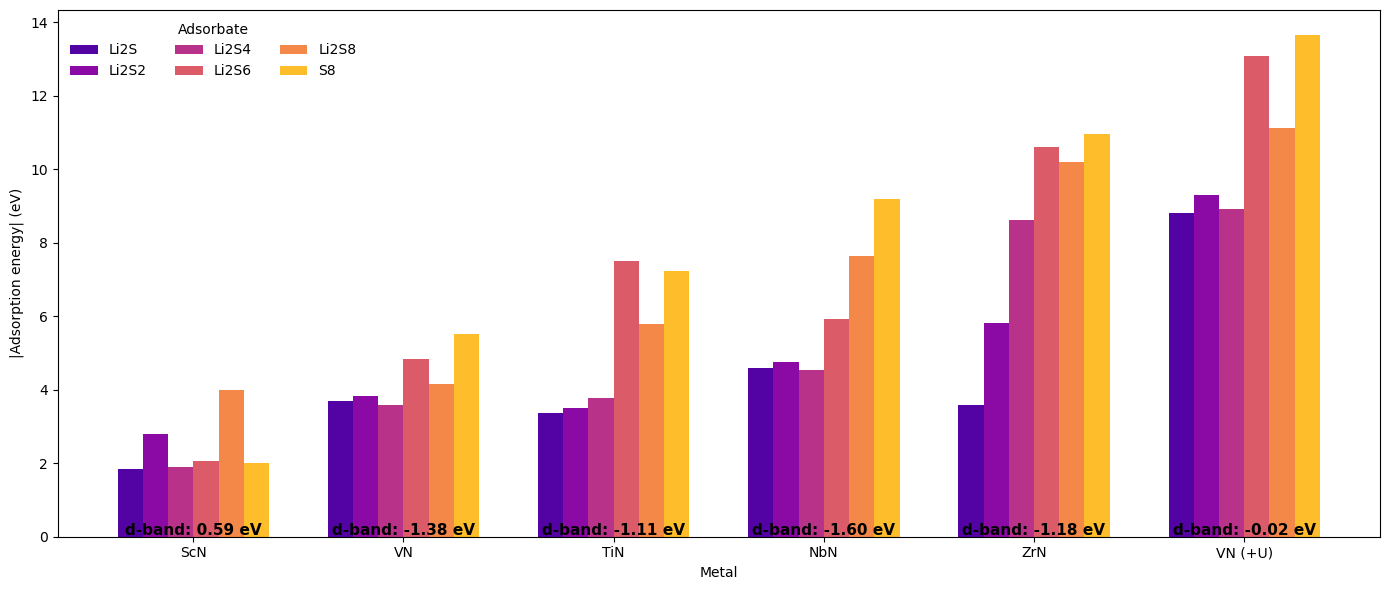

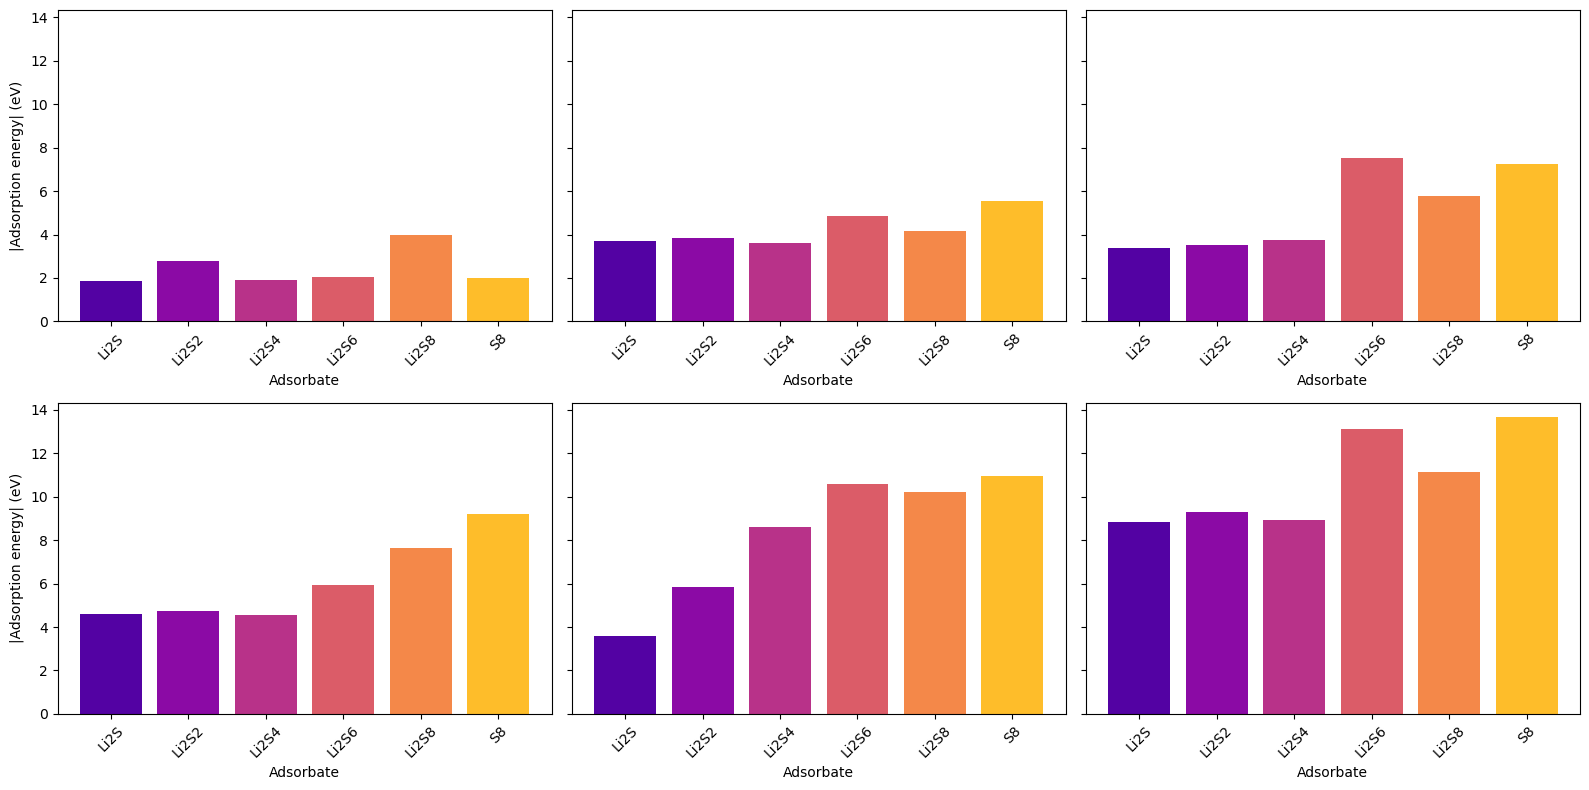

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = Path('/home/ameer_ubuntu/Git_projects/QE_2')
primary_csv = base_dir / 'no_u/combi_144/adsorption_energies_from_outs.csv'
plus_u_csv = base_dir / 'u/combi/final_xyz/adsorption_energies.csv'
dband_csv = base_dir / 'Final_plots/d_band_values.csv'

ads_order = ['Li2S', 'Li2S2', 'Li2S4', 'Li2S6', 'Li2S8', 'S8']

# Create plasma color scheme (S8 = yellow/lightest, Li2S = dark).
colors = sns.color_palette('plasma', len(ads_order))
adsorbate_colors = dict(zip(ads_order, colors))

# Load and normalize both datasets.
df_primary = pd.read_csv(primary_csv)
df_plus_u = pd.read_csv(plus_u_csv)

# Keep only VN from the second CSV, then relabel it as VN (+U).
df_plus_u = df_plus_u[df_plus_u['surface'] == 'VN'].copy()

# Keep only the columns we need, and standardize names.
df_primary = df_primary.rename(columns={'slab': 'metal'})[['metal', 'adsorbate', 'E_adsorption_eV']].copy()
df_plus_u = df_plus_u.rename(columns={'surface': 'metal'})[['metal', 'adsorbate', 'E_adsorption_eV']].copy()
df_plus_u['metal'] = df_plus_u['metal'].replace({'VN': 'VN (+U)'})

# Make adsorption energies positive for plotting.
df_primary['E_adsorption_eV'] = df_primary['E_adsorption_eV'].abs()
df_plus_u['E_adsorption_eV'] = df_plus_u['E_adsorption_eV'].abs()

df = pd.concat([df_primary, df_plus_u], ignore_index=True)

# Order metals by lowest average adsorption energy (left to right).
metal_order = df.groupby('metal')['E_adsorption_eV'].mean().sort_values().index.tolist()

df['metal'] = pd.Categorical(df['metal'], categories=metal_order, ordered=True)
df['adsorbate'] = pd.Categorical(df['adsorbate'], categories=ads_order, ordered=True)
df = df.sort_values(['metal', 'adsorbate']).reset_index(drop=True)

display(df)

# Load d-band center values and compute max per metal.
dband_df = pd.read_csv(dband_csv)
dband_max = dband_df.groupby('compound')['d_band_center_eV'].max().to_dict()

# --- Plot 1: grouped bars, metals on x-axis and adsorbates as separate bars ---
fig, ax = plt.subplots(figsize=(14, 6))

metal_positions = range(len(metal_order))
bar_width = 0.12
offsets = [
    (i - (len(ads_order) - 1) / 2) * bar_width
    for i in range(len(ads_order))
]

for ads_idx, ads in enumerate(ads_order):
    heights = []
    for metal in metal_order:
        subset = df[(df['metal'] == metal) & (df['adsorbate'] == ads)]
        heights.append(subset['E_adsorption_eV'].iloc[0] if not subset.empty else float('nan'))

    ax.bar(
        [pos + offsets[ads_idx] for pos in metal_positions],
        heights,
        width=bar_width,
        label=ads,
        color=adsorbate_colors[ads],
    )

ax.set_xticks(list(metal_positions))
ax.set_xticklabels(metal_order)
ax.set_xlabel('Metal')
ax.set_ylabel('|Adsorption energy| (eV)')
ax.legend(title='Adsorbate', ncol=3, frameon=False, loc='upper left')

# Annotate each metal with its highest d-band center value.
for pos, metal in enumerate(metal_order):
    val = dband_max.get(metal, None)
    if val is not None:
        ax.annotate(
            f"d-band: {val:.2f} eV",
            xy=(pos, 0),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            va='top',
            fontsize=11,
            fontweight='bold',
        )

plt.tight_layout()
plt.savefig(base_dir / 'Final_plots' / 'Figure_1a.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Plot 2: one subplot per metal, with the six adsorbates on the x-axis ---
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for idx, (ax, metal) in enumerate(zip(axes, metal_order)):
    subset = df[df['metal'] == metal].set_index('adsorbate').reindex(ads_order)
    values = subset['E_adsorption_eV'].tolist()

    ax.bar(ads_order, values, color=[adsorbate_colors[a] for a in ads_order])
    ax.set_xlabel('Adsorbate')
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('|Adsorption energy| (eV)')
axes[3].set_ylabel('|Adsorption energy| (eV)')
plt.tight_layout()
plt.savefig(base_dir / 'Final_plots' / 'Figure_1b.png', dpi=300, bbox_inches='tight')
plt.show()


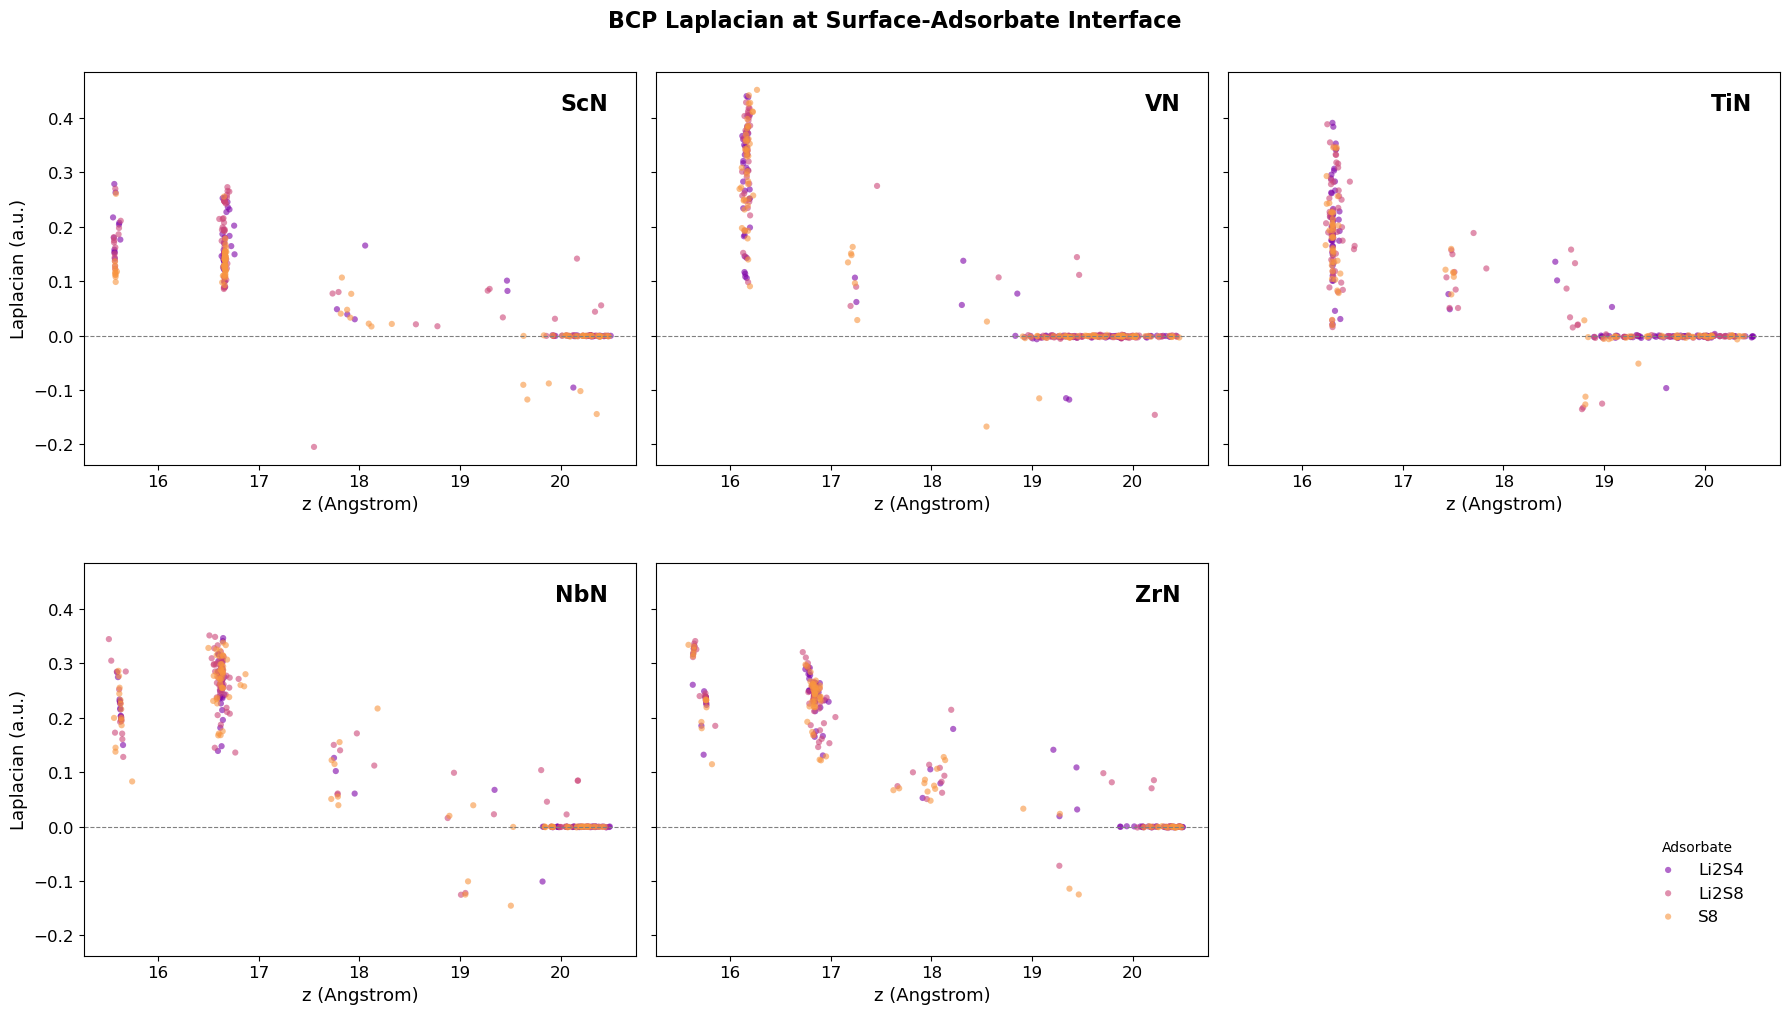

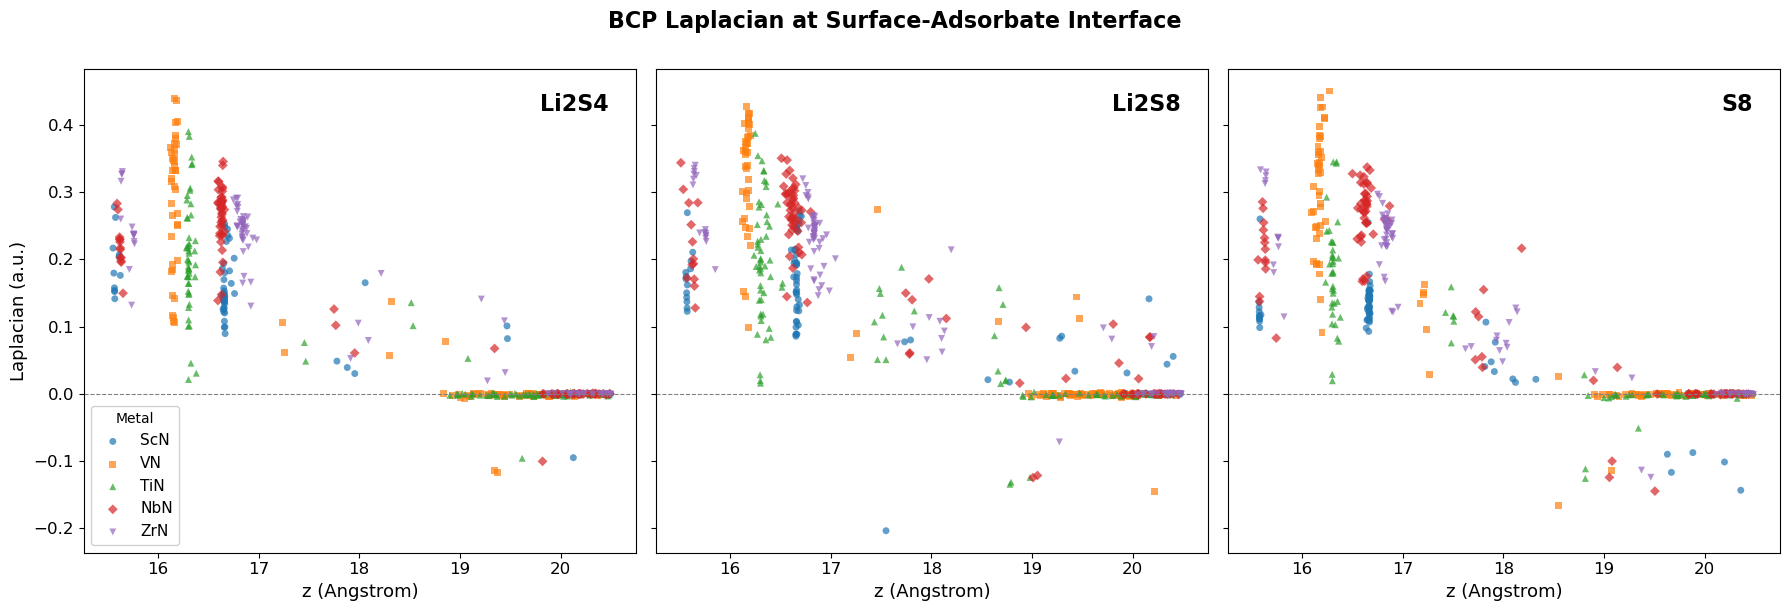

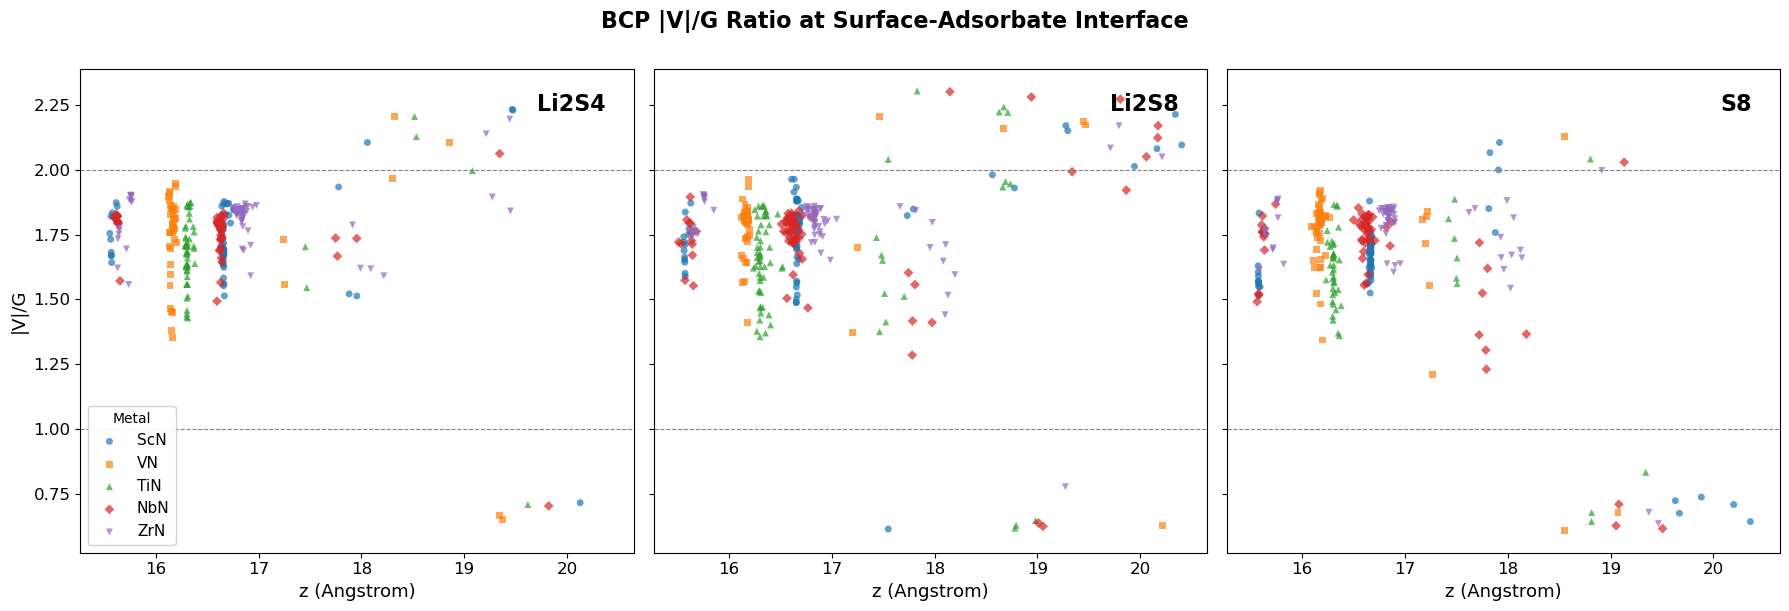

In [12]:
# --- Plot 3: BCP Laplacian scatter, one subplot per metal ---
bcp_dir = base_dir / 'no_u/PDOS/bcp_laplacian_cro'

metal_order_bcp = ['ScN', 'VN', 'TiN', 'NbN', 'ZrN']
ads_order_bcp = ['Li2S4', 'Li2S8', 'S8']
ads_colors_bcp = dict(zip(ads_order_bcp, sns.color_palette('plasma', len(ads_order_bcp))))

bcp_data = []
for csv_path in sorted(bcp_dir.glob('*/*.csv')):
    stem = csv_path.stem.replace('_bcp_laplacian', '')
    if stem == 'analysis':
        continue
    metal, ads = stem.split('_', 1)
    df_tmp = pd.read_csv(csv_path)
    df_tmp['metal'] = metal
    df_tmp['adsorbate'] = ads
    bcp_data.append(df_tmp)

bcp_df = pd.concat(bcp_data, ignore_index=True)
bcp_df = bcp_df[bcp_df['laplacian'].abs() < 1.0]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True, sharex=True)
axes_flat = axes.ravel()

for idx, metal in enumerate(metal_order_bcp):
    ax = axes_flat[idx]
    for ads in ads_order_bcp:
        subset = bcp_df[(bcp_df['metal'] == metal) & (bcp_df['adsorbate'] == ads)]
        if subset.empty:
            continue
        ax.scatter(
            subset['z_ang'],
            subset['laplacian'],
            s=20,
            alpha=0.6,
            color=ads_colors_bcp[ads],
            label=ads,
            edgecolors='none',
        )
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.annotate(metal, xy=(0.95, 0.95), xycoords='axes fraction',
                fontsize=16, fontweight='bold', ha='right', va='top')
    ax.tick_params(axis='both', labelsize=12, labelbottom=True)
    ax.set_xlabel('z (Angstrom)', fontsize=13)
    if idx % 3 == 0:
        ax.set_ylabel('Laplacian (a.u.)', fontsize=13)

axes_flat[-1].axis('off')
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Adsorbate', loc='lower right',
           bbox_to_anchor=(0.98, 0.08), frameon=False, fontsize=12)

fig.suptitle('BCP Laplacian at Surface-Adsorbate Interface', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(hspace=0.25)
plt.savefig(base_dir / 'Final_plots' / 'Figure_bcp_laplacian.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Plot 4: BCP Laplacian scatter, one subplot per adsorbate ---
metal_colors_bcp = dict(zip(metal_order_bcp, sns.color_palette('tab10', len(metal_order_bcp))))

metal_markers = dict(zip(metal_order_bcp, ['o', 's', '^', 'D', 'v']))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)

for idx, ads in enumerate(ads_order_bcp):
    ax = axes[idx]
    for metal in metal_order_bcp:
        subset = bcp_df[(bcp_df['metal'] == metal) & (bcp_df['adsorbate'] == ads)]
        if subset.empty:
            continue
        ax.scatter(
            subset['z_ang'],
            subset['laplacian'],
            s=25,
            alpha=0.7,
            color=metal_colors_bcp[metal],
            marker=metal_markers[metal],
            label=metal,
            edgecolors='none',
        )
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.annotate(ads, xy=(0.95, 0.95), xycoords='axes fraction',
                fontsize=16, fontweight='bold', ha='right', va='top')
    ax.tick_params(axis='both', labelsize=12, labelbottom=True)
    ax.set_xlabel('z (Angstrom)', fontsize=13)
    if idx == 0:
        ax.set_ylabel('Laplacian (a.u.)', fontsize=13)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title='Metal', loc='lower left',
               frameon=True, fontsize=11, framealpha=0.9)

fig.suptitle('BCP Laplacian at Surface-Adsorbate Interface', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(base_dir / 'Final_plots' / 'Figure_bcp_laplacian_by_ads.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Plot 5: |V|/G scatter, one subplot per adsorbate ---
bcp_vg = bcp_df[(bcp_df['rho'] > 0.01) & (bcp_df['G_ked'] > 0)].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)

for idx, ads in enumerate(ads_order_bcp):
    ax = axes[idx]
    for metal in metal_order_bcp:
        subset = bcp_vg[(bcp_vg['metal'] == metal) & (bcp_vg['adsorbate'] == ads)]
        if subset.empty:
            continue
        ax.scatter(
            subset['z_ang'],
            subset['abs_V_over_G'],
            s=25,
            alpha=0.7,
            color=metal_colors_bcp[metal],
            marker=metal_markers[metal],
            label=metal,
            edgecolors='none',
        )
    ax.axhline(1, color='grey', linewidth=0.8, linestyle='--')
    ax.axhline(2, color='grey', linewidth=0.8, linestyle='--')
    ax.annotate(ads, xy=(0.95, 0.95), xycoords='axes fraction',
                fontsize=16, fontweight='bold', ha='right', va='top')
    ax.tick_params(axis='both', labelsize=12, labelbottom=True)
    ax.set_xlabel('z (Angstrom)', fontsize=13)
    if idx == 0:
        ax.set_ylabel('|V|/G', fontsize=13)

axes[0].legend(handles, labels, title='Metal', loc='lower left',
               frameon=True, fontsize=11, framealpha=0.9)

fig.suptitle('BCP |V|/G Ratio at Surface-Adsorbate Interface', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(base_dir / 'Final_plots' / 'Figure_bcp_V_over_G.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_171601/3827790723.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(icohp_ads.groupby(['metal', 'adsorbate', 'interaction']).agg(


mean_ICOHP  mean_abs_ICOHP  count
metal adsorbate interaction                                   
NbN   Li2S4     Li-Metal        -0.3719          0.3719     16
                S-Metal         -2.6124          2.6124      4
                Li-N            -0.5540          0.5540      4
                S-N             -0.0758          0.0758     12
      Li2S8     Li-Metal        -0.3834          0.3834      6
                S-Metal         -3.8141          3.8141     12
                Li-N            -0.4090          0.4090      2
                S-N             -0.0446          0.0446     40
      S8        Li-Metal            NaN             NaN      0
                S-Metal         -3.3033          3.3033     16
                Li-N                NaN             NaN      0
                S-N             -0.0434          0.0438     50
ScN   Li2S4     Li-Metal        -0.3249          0.3249     16
                S-Metal         -1.9352          1.9352      4
                Li-N            -0.6180          0.6180      4
                S-N             -0.0957          0.0957      8
      Li2S8     Li-Metal        -0.3254          0.3254      4
                S-Metal         -1.1030          1.1030     20
                Li-N            -0.0704          0.0704      2
                S-N             -2.2841          2.2841     12
      S8        Li-Metal            NaN             NaN      0
                S-Metal         -1.0171          1.0171     10
                Li-N                NaN             NaN      0
                S-N             -0.0776          0.0776     14
TiN   Li2S4     Li-Metal        -0.3276          0.3276     16
                S-Metal         -1.9709          1.9709      4
                Li-N            -0.5936          0.5936      4
                S-N             -0.0893          0.0893     12
      Li2S8     Li-Metal        -0.2954          0.2954     16
                S-Metal         -1.6087          1.6087     28
                Li-N            -0.3318          0.3318      4
                S-N             -0.0548          0.0548     46
      S8        Li-Metal            NaN             NaN      0
                S-Metal         -1.3709          1.3709     24
                Li-N                NaN             NaN      0
                S-N             -0.0465          0.0465     44
VN    Li2S4     Li-Metal        -0.3159          0.3159     16
                S-Metal         -1.3899          1.3899      6
                Li-N            -0.2529          0.2529     12
                S-N             -0.1212          0.1212     12
      Li2S8     Li-Metal        -0.3224          0.3224      8
                S-Metal         -1.4569          1.4569      6
                Li-N            -0.2465          0.2465      6
                S-N             -0.0864          0.0864     16
      S8        Li-Metal            NaN             NaN      0
                S-Metal         -1.5584          1.5584     18
                Li-N                NaN             NaN      0
                S-N             -0.0849          0.0849     42
ZrN   Li2S4     Li-Metal        -0.3006          0.3006     14
                S-Metal         -2.7290          2.7290     12
                Li-N            -0.2759          0.2759      4
                S-N             -0.0323          0.0323     16
      Li2S8     Li-Metal            NaN             NaN      0
                S-Metal         -2.6488          2.6488     18
                Li-N            -0.0560          0.0560      2
                S-N             -0.0802          0.0802     20
      S8        Li-Metal            NaN             NaN      0
                S-Metal         -2.0219          2.0219     26
                Li-N                NaN             NaN      0
                S-N             -0.0290          0.0290     28

/tmp/ipykernel_171601/3827790723.py:103: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(icohp_ads.groupby(['metal', 'adsorbate', 'bond_type']).agg(


count
metal adsorbate bond_type             
NbN   Li2S4     Strong covalent      4
                Moderate             0
                Weak                 4
                Negligible          28
      Li2S8     Strong covalent     12
                Moderate             0
                Weak                 0
                Negligible          48
      S8        Strong covalent     14
                Moderate             0
                Weak                 0
                Negligible          52
ScN   Li2S4     Strong covalent      2
                Moderate             2
                Weak                 4
                Negligible          24
      Li2S8     Strong covalent      4
                Moderate            12
                Weak                 8
                Negligible          14
      S8        Strong covalent      0
                Moderate             6
                Weak                 0
                Negligible          18
TiN   Li2S4     Strong covalent      0
                Moderate             4
                Weak                 4
                Negligible          28
      Li2S8     Strong covalent     14
                Moderate             0
                Weak                 0
                Negligible          80
      S8        Strong covalent      8
                Moderate             6
                Weak                 0
                Negligible          54
VN    Li2S4     Strong covalent      2
                Moderate             2
                Weak                 4
                Negligible          38
      Li2S8     Strong covalent      2
                Moderate             2
                Weak                 2
                Negligible          30
      S8        Strong covalent     12
                Moderate             0
                Weak                 0
                Negligible          48
ZrN   Li2S4     Strong covalent      8
                Moderate             2
                Weak                 0
                Negligible          36
      Li2S8     Strong covalent     12
                Moderate             6
                Weak                 0
                Negligible          22
      S8        Strong covalent     14
                Moderate            10
                Weak                 0
                Negligible          30

/tmp/ipykernel_171601/3827790723.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = subset.groupby(['metal', 'interaction'])['abs_icohp'].mean().unstack(fill_value=0)
/tmp/ipykernel_171601/3827790723.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = subset.groupby(['metal', 'interaction'])['abs_icohp'].mean().unstack(fill_value=0)
/tmp/ipykernel_171601/3827790723.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silen

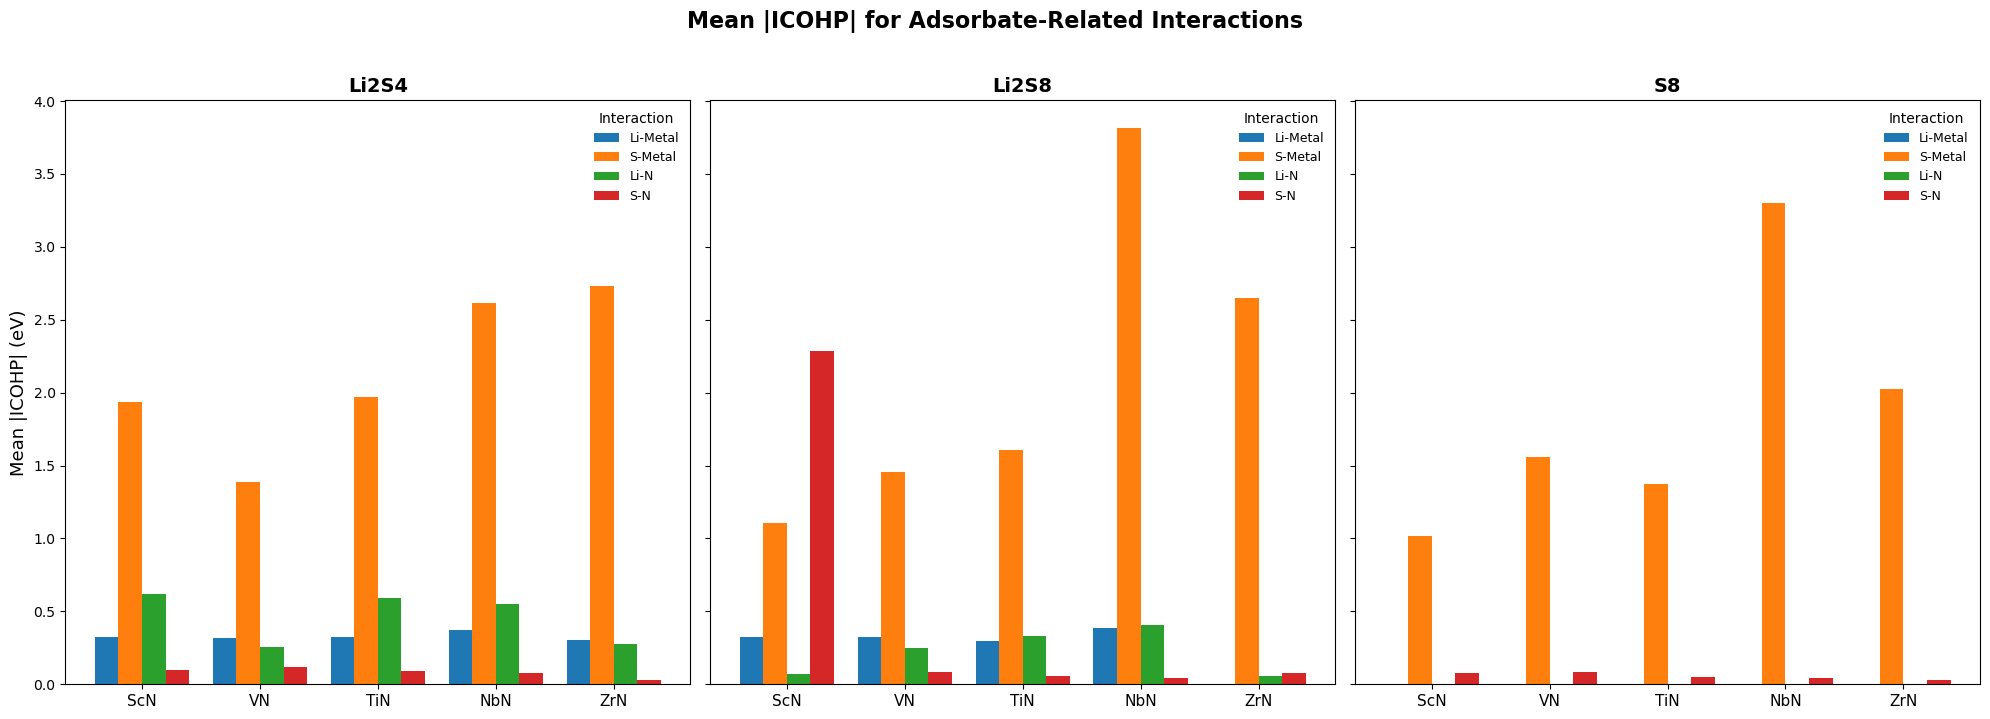

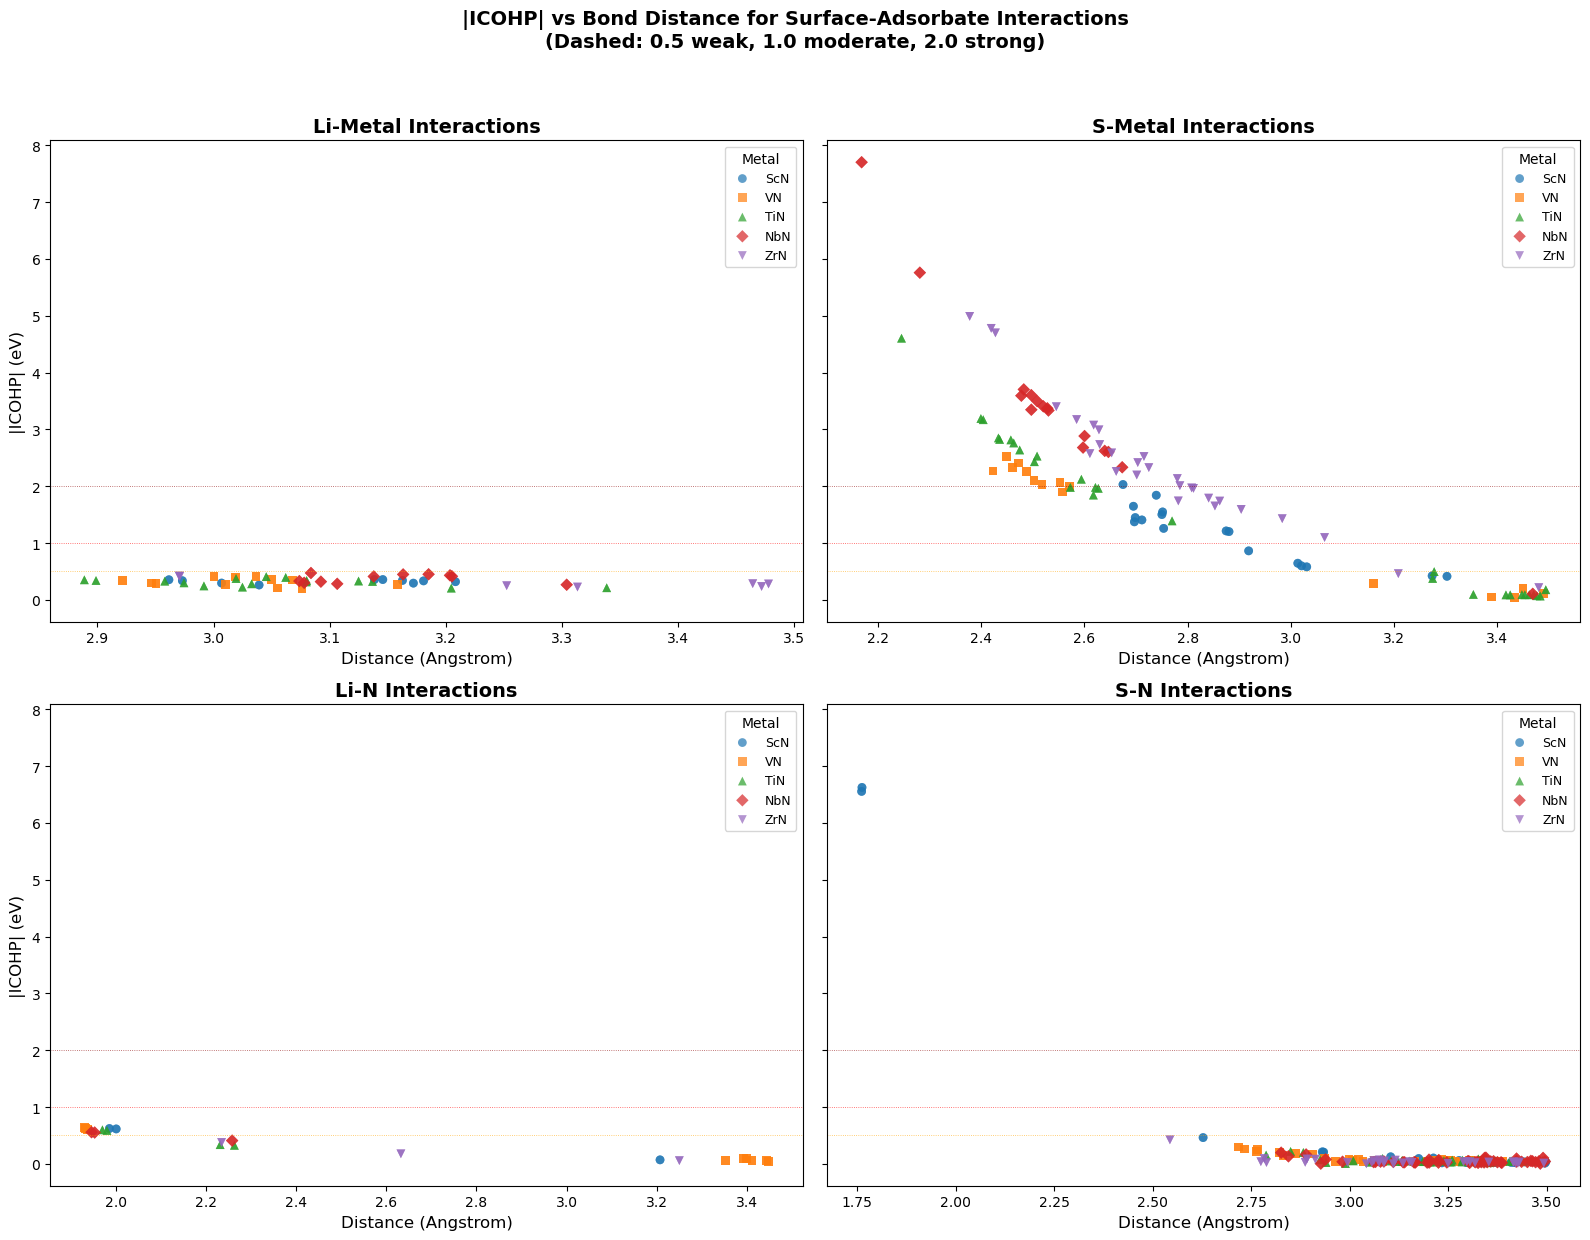

/tmp/ipykernel_171601/3827790723.py:174: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frac = subset.groupby(['metal', 'bond_type']).size().unstack(fill_value=0)
/tmp/ipykernel_171601/3827790723.py:174: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frac = subset.groupby(['metal', 'bond_type']).size().unstack(fill_value=0)
/tmp/ipykernel_171601/3827790723.py:174: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frac = subset

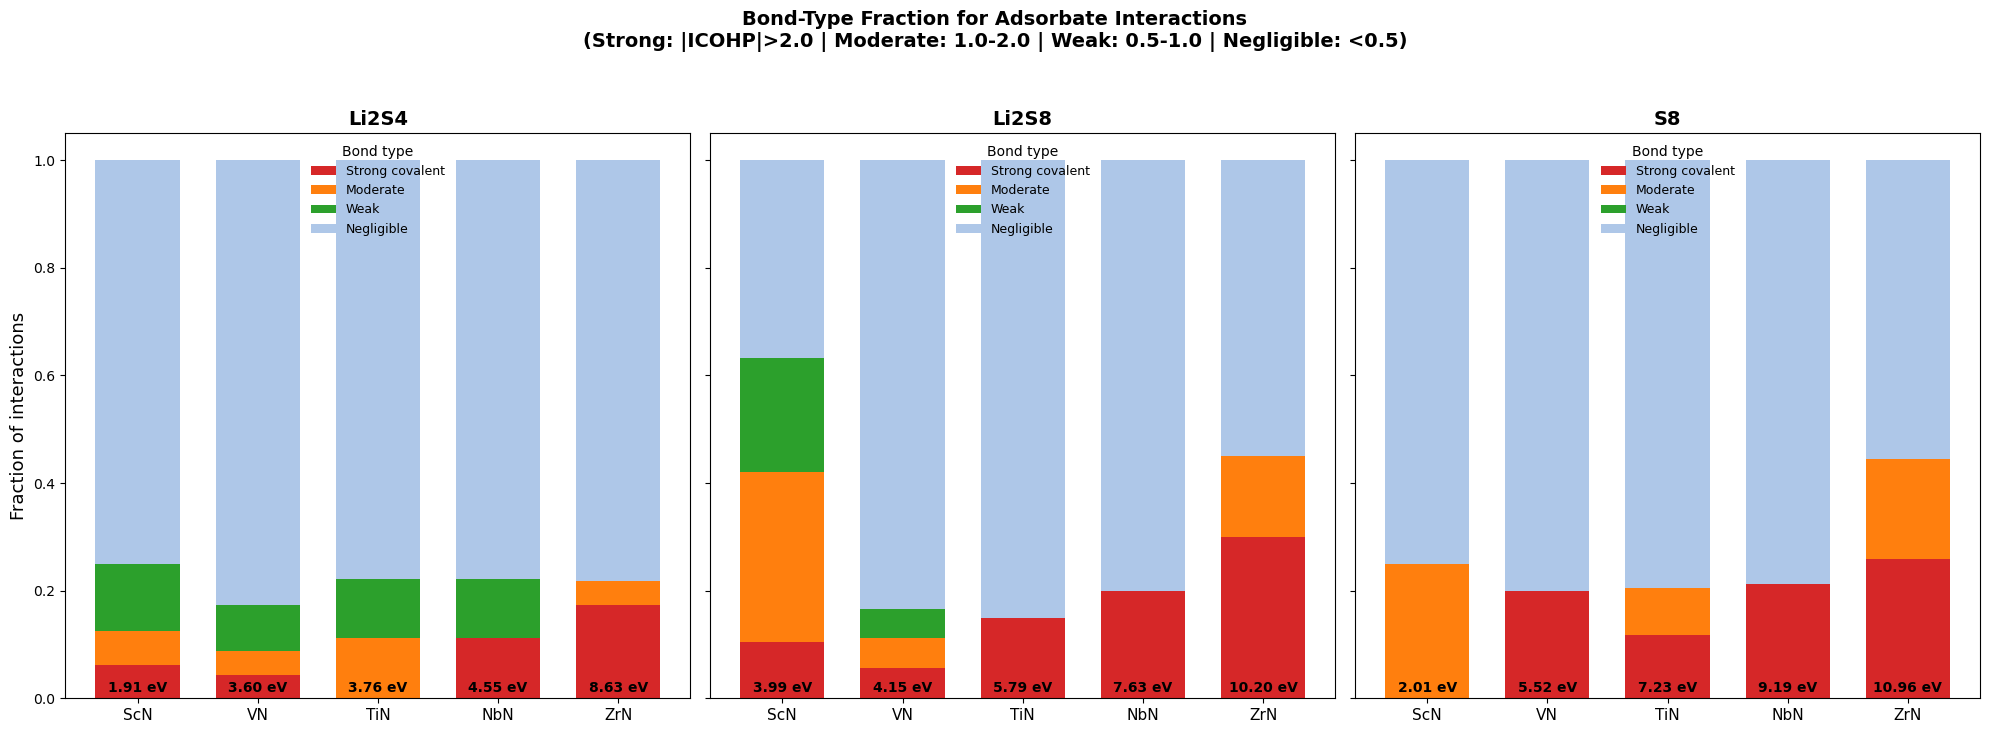

In [20]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

base_dir = Path('/home/ameer_ubuntu/Git_projects/QE_2')
icohp_dir = base_dir / 'no_u/lobster_icohp'

metal_order_icohp = ['ScN', 'VN', 'TiN', 'NbN', 'ZrN']
ads_order_icohp = ['Li2S4', 'Li2S8', 'S8']

def parse_icohp(filepath):
    rows = []
    with open(filepath) as f:
        lines = f.readlines()
    for line in lines[2:]:
        parts = line.split()
        if len(parts) < 7:
            continue
        rows.append({
            'cohp_idx': int(parts[0]),
            'atom1': parts[1],
            'atom2': parts[2],
            'distance': float(parts[3]),
            'translation': tuple(int(x) for x in parts[4:7]),
            'icohp': float(parts[7]),
        })
    return pd.DataFrame(rows)

def get_element(atom_label):
    return re.match(r'([A-Za-z]+)', atom_label).group(1)

def classify_bond_type(abs_icohp):
    if abs_icohp > 2.0:
        return 'Strong covalent'
    elif abs_icohp > 1.0:
        return 'Moderate'
    elif abs_icohp > 0.5:
        return 'Weak'
    else:
        return 'Negligible'

all_data = []
for subdir in sorted(icohp_dir.iterdir()):
    if not subdir.is_dir():
        continue
    icohp_file = subdir / 'ICOHPLIST.lobster'
    if not icohp_file.exists():
        continue
    name = subdir.name.replace('_combi', '')
    parts = name.split('_', 1)
    metal = parts[0]
    ads = parts[1] if len(parts) > 1 else ''
    if metal not in metal_order_icohp or ads not in ads_order_icohp:
        continue
    df_tmp = parse_icohp(icohp_file)
    df_tmp['metal'] = metal
    df_tmp['adsorbate'] = ads
    df_tmp['elem1'] = df_tmp['atom1'].apply(get_element)
    df_tmp['elem2'] = df_tmp['atom2'].apply(get_element)
    all_data.append(df_tmp)

icohp_df = pd.concat(all_data, ignore_index=True)

adsorbate_elements = {'Li', 'S'}
surface_elements = {'Sc', 'V', 'Ti', 'Nb', 'Zr', 'N'}

def interaction_type(row):
    e1, e2 = row['elem1'], row['elem2']
    a1 = e1 in adsorbate_elements
    a2 = e2 in adsorbate_elements
    s1 = e1 in surface_elements
    s2 = e2 in surface_elements
    if (a1 and s2) or (a2 and s1):
        ads_elem = e1 if a1 else e2
        surf_elem = e2 if a1 else e1
        if surf_elem == 'N':
            return f'{ads_elem}-N'
        else:
            return f'{ads_elem}-Metal'
    return None

icohp_df['interaction'] = icohp_df.apply(interaction_type, axis=1)
icohp_ads = icohp_df[icohp_df['interaction'].notna()].copy()
icohp_ads['abs_icohp'] = icohp_ads['icohp'].abs()
icohp_ads['bond_type'] = icohp_ads['abs_icohp'].apply(classify_bond_type)

interaction_order = ['Li-Metal', 'S-Metal', 'Li-N', 'S-N']
bond_type_order = ['Strong covalent', 'Moderate', 'Weak', 'Negligible']

icohp_ads['interaction'] = pd.Categorical(icohp_ads['interaction'], categories=interaction_order, ordered=True)
icohp_ads['bond_type'] = pd.Categorical(icohp_ads['bond_type'], categories=bond_type_order, ordered=True)

display(icohp_ads.groupby(['metal', 'adsorbate', 'interaction']).agg(
    mean_ICOHP=('icohp', 'mean'),
    mean_abs_ICOHP=('abs_icohp', 'mean'),
    count=('icohp', 'count')
).round(4))

display(icohp_ads.groupby(['metal', 'adsorbate', 'bond_type']).agg(
    count=('icohp', 'count')
))

metal_colors_icohp = dict(zip(metal_order_icohp, sns.color_palette('tab10', len(metal_order_icohp))))
ads_colors_icohp = dict(zip(ads_order_icohp, sns.color_palette('plasma', len(ads_order_icohp))))

# --- Plot 6: Mean |ICOHP| per interaction type, grouped by metal and adsorbate ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

for idx, ads in enumerate(ads_order_icohp):
    ax = axes[idx]
    subset = icohp_ads[icohp_ads['adsorbate'] == ads]
    pivot = subset.groupby(['metal', 'interaction'])['abs_icohp'].mean().unstack(fill_value=0)
    pivot = pivot.reindex(index=metal_order_icohp, columns=interaction_order).fillna(0)
    pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='none')
    ax.set_title(ads, fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(metal_order_icohp, rotation=0, fontsize=11)
    if idx == 0:
        ax.set_ylabel('Mean |ICOHP| (eV)', fontsize=13)
    ax.legend(title='Interaction', fontsize=9, title_fontsize=10, frameon=False)

fig.suptitle('Mean |ICOHP| for Adsorbate-Related Interactions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(base_dir / 'Final_plots' / 'Figure_icohp_mean_by_interaction.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Plot 9: Scatter of ICOHP vs distance for surface-adsorbate interactions ---
key_interactions = ['Li-Metal', 'S-Metal', 'Li-N', 'S-N']
scatter_df = icohp_ads[icohp_ads['interaction'].isin(key_interactions)]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes_flat = axes.ravel()

for idx, inter in enumerate(key_interactions):
    ax = axes_flat[idx]
    subset = scatter_df[scatter_df['interaction'] == inter]
    metal_markers_icohp = dict(zip(metal_order_icohp, ['o', 's', '^', 'D', 'v']))
    for metal in metal_order_icohp:
        m_sub = subset[subset['metal'] == metal]
        if m_sub.empty:
            continue
        ax.scatter(
            m_sub['distance'], m_sub['abs_icohp'],
            s=40, alpha=0.7,
            color=metal_colors_icohp[metal],
            marker=metal_markers_icohp[metal],
            label=metal, edgecolors='none',
        )
    ax.axhline(0.5, color='orange', linewidth=0.6, linestyle=':', alpha=0.7)
    ax.axhline(1.0, color='red', linewidth=0.6, linestyle=':', alpha=0.7)
    ax.axhline(2.0, color='darkred', linewidth=0.6, linestyle=':', alpha=0.7)
    ax.set_title(f'{inter} Interactions', fontsize=14, fontweight='bold')
    ax.set_xlabel('Distance (Angstrom)', fontsize=12)
    if idx % 2 == 0:
        ax.set_ylabel('|ICOHP| (eV)', fontsize=12)
    ax.legend(title='Metal', fontsize=9, title_fontsize=10, frameon=True, framealpha=0.8)

fig.suptitle('|ICOHP| vs Bond Distance for Surface-Adsorbate Interactions\n(Dashed: 0.5 weak, 1.0 moderate, 2.0 strong)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(base_dir / 'Final_plots' / 'Figure_icohp_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Plot 10: Stacked bar of bond-type fractions per metal/adsorbate ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

for idx, ads in enumerate(ads_order_icohp):
    ax = axes[idx]
    subset = icohp_ads[icohp_ads['adsorbate'] == ads]
    frac = subset.groupby(['metal', 'bond_type']).size().unstack(fill_value=0)
    frac = frac.div(frac.sum(axis=1), axis=0)
    frac = frac.reindex(index=metal_order_icohp, columns=bond_type_order).fillna(0)
    frac.plot(kind='bar', stacked=True, ax=ax, width=0.7,
              color=['#d62728', '#ff7f0e', '#2ca02c', '#aec7e8'], edgecolor='none')
    ax.set_title(ads, fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(metal_order_icohp, rotation=0, fontsize=11)
    ax.set_ylim(0, 1.05)
    if idx == 0:
        ax.set_ylabel('Fraction of interactions', fontsize=13)
    ax.legend(title='Bond type', fontsize=9, title_fontsize=10, frameon=False)

ads_csv = base_dir / 'no_u/combi_144/adsorption_energies_from_outs.csv'
ads_df = pd.read_csv(ads_csv)[['slab', 'adsorbate', 'E_adsorption_eV']].copy()
ads_df = ads_df.rename(columns={'slab': 'metal'})
ads_df['E_adsorption_eV'] = ads_df['E_adsorption_eV'].abs()

for idx, ads in enumerate(ads_order_icohp):
    ax = axes[idx]
    for pos, metal in enumerate(metal_order_icohp):
        row = ads_df[(ads_df['metal'] == metal) & (ads_df['adsorbate'] == ads)]
        if row.empty:
            continue
        val = row['E_adsorption_eV'].values[0]
        ax.annotate(
            f'{val:.2f} eV',
            xy=(pos, 0.03), xycoords=('data', 'axes fraction'),
            ha='center', va='top', fontsize=10, fontweight='bold', color='black',
        )

fig.suptitle('Bond-Type Fraction for Adsorbate Interactions\n(Strong: |ICOHP|>2.0 | Moderate: 1.0-2.0 | Weak: 0.5-1.0 | Negligible: <0.5)',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(base_dir / 'Final_plots' / 'Figure_icohp_bond_fractions.png', dpi=300, bbox_inches='tight')
plt.show()